# Steam Game Recommender — Check-in 1 EDA

This notebook audits the two project datasets:

- `user_games.parquet` — 11,285,290 user–game interaction rows
- `games.parquet` — 47,811 Steam game metadata rows

The goal is to understand the data well enough to define a feasible recommendation task, identify artifacts/biases, and establish an evaluation plan.

## 1. Imports and paths

In [1]:
%pip install duckdb
from pathlib import Path
import json
import math
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
USER_GAMES_PATH = RAW_DATA_DIR / "user_games.parquet"
GAMES_PATH = RAW_DATA_DIR / "games.parquet"
MANIFEST_PATH = RAW_DATA_DIR / "manifest.json"

assert USER_GAMES_PATH.exists(), f"Missing: {USER_GAMES_PATH}"
assert GAMES_PATH.exists(), f"Missing: {GAMES_PATH}"
assert MANIFEST_PATH.exists(), f"Missing: {MANIFEST_PATH}"

print("Project root:", PROJECT_ROOT)
print("User-games:", USER_GAMES_PATH)
print("Games:", GAMES_PATH)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 43.8 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.
Project root: /Users/robertgeorge/Desktop/DSAN Files/6600/dsan6600-finalproject
User-games: /Users/robertgeorge/Desktop/DSAN Files/6600/dsan6600-finalproject/data/raw/user_games.parquet
Games: /Users/robertgeorge/Desktop/DSAN Files/6600/dsan6600-finalproject/data/raw/games.parquet


## 2. Dataset manifest

In [2]:
with MANIFEST_PATH.open("r", encoding="utf-8") as f:
    manifest = json.load(f)

manifest

{'dataset_id': 'frankjc2022/steam-dataset',
 'source_url': 'https://huggingface.co/datasets/frankjc2022/steam-dataset',
 'downloaded_at_utc': '2026-10-01T01:09:36.721241+00:00',
 'configs': [{'config': 'user_games',
   'rows': 11285290,
   'columns': 9,
   'column_names': ['steamid',
    'appid',
    'game_count',
    'game_name',
    'playtime_forever',
    'img_icon_url',
    'has_community_visible_stats',
    'has_leaderboards',
    'content_descriptorids'],
   'output': 'data/raw/user_games.parquet',
   'size_mb': 512.48,
   'status': 'downloaded'},
  {'config': 'games',
   'rows': 47811,
   'columns': 29,
   'column_names': ['appid',
    'type',
    'name',
    'is_free',
    'required_age',
    'short_description',
    'detailed_description',
    'about_the_game',
    'supported_languages',
    'developers',
    'publishers',
    'platforms',
    'categories',
    'genres',
    'pc_requirements',
    'mac_requirements',
    'linux_requirements',
    'price_currency',
    'price_i

### Dataset source and access notes

The project uses `frankjc2022/steam-dataset` from Hugging Face.

For Check-in 1, the two required configurations are:

- **`user_games`**: user/game interaction records
- **`games`**: Steam game metadata

The raw Parquet files are kept under `data/raw/` and should remain excluded from Git because of their size.

## 3. Connect to the Parquet files

In [3]:
con = duckdb.connect()

user_games_sql = str(USER_GAMES_PATH).replace("'", "''")
games_sql = str(GAMES_PATH).replace("'", "''")

con.execute(f"""
CREATE OR REPLACE VIEW user_games AS
SELECT * FROM read_parquet('{user_games_sql}')
""")

con.execute(f"""
CREATE OR REPLACE VIEW games AS
SELECT * FROM read_parquet('{games_sql}')
""")

print("DuckDB views created.")

DuckDB views created.


## 4. Inspect schemas

In [4]:
print("USER_GAMES SCHEMA")
display(con.execute("DESCRIBE user_games").df())

print("\nGAMES SCHEMA")
display(con.execute("DESCRIBE games").df())

USER_GAMES SCHEMA


,column_name,column_type,null,key,default,extra
0,steamid,VARCHAR,YES,None,None,None
1,appid,INTEGER,YES,None,None,None
2,game_count,INTEGER,YES,None,None,None
3,game_name,VARCHAR,YES,None,None,None
4,playtime_forever,INTEGER,YES,None,None,None
5,img_icon_url,VARCHAR,YES,None,None,None
6,has_community_visible_stats,BOOLEAN,YES,None,None,None
7,has_leaderboards,BOOLEAN,YES,None,None,None
8,content_descriptorids,BIGINT[],YES,None,None,None



GAMES SCHEMA


,column_name,column_type,null,key,default,extra
0,appid,INTEGER,YES,None,None,None
1,type,VARCHAR,YES,None,None,None
2,name,VARCHAR,YES,None,None,None
3,is_free,BOOLEAN,YES,None,None,None
4,required_age,INTEGER,YES,None,None,None
5,short_description,VARCHAR,YES,None,None,None
6,detailed_description,VARCHAR,YES,None,None,None
7,about_the_game,VARCHAR,YES,None,None,None
8,supported_languages,VARCHAR,YES,None,None,None
9,developers,VARCHAR[],YES,None,None,None


## 5. Representative samples

In [5]:
print("user_games sample")
display(con.execute("""
    SELECT *
    FROM user_games
    LIMIT 10
""").df())

print("games sample")
display(con.execute("""
    SELECT
        appid,
        name,
        type,
        is_free,
        required_age,
        developers,
        publishers,
        genres,
        price_final,
        metacritic_score,
        recommendations_total,
        release_date
    FROM games
    LIMIT 10
""").df())

user_games sample


,steamid,appid,game_count,game_name,playtime_forever,img_icon_url,has_community_visible_stats,has_leaderboards,content_descriptorids
0,76561197960293516,10,13024,Counter-Strike,599979,6b0312cda02f5f777efa2f3318c307ff9acafbb5,False,False,"[2, 5]"
1,76561197960293516,20,13024,Team Fortress Classic,0,38ea7ebe3c1abbbbf4eabdbef174c41a972102b9,False,False,"[2, 5]"
2,76561197960293516,30,13024,Day of Defeat,0,aadc0ce51ff6ba2042d633f8ec033b0de62091d0,False,False,"[2, 5]"
3,76561197960293516,40,13024,Deathmatch Classic,0,c525f76c8bc7353db4fd74b128c4ae2028426c2a,False,False,[]
4,76561197960293516,50,13024,Half-Life: Opposing Force,0,04e81206c10e12416908c72c5f22aad411b3aeef,False,False,"[2, 5]"
5,76561197960293516,60,13024,Ricochet,0,98c69e04cd59b838e05cb6980c12c05874c6419e,False,False,[]
6,76561197960293516,70,13024,Half-Life,3,95be6d131fc61f145797317ca437c9765f24b41c,False,False,"[2, 5]"
7,76561197960293516,80,13024,Counter-Strike: Condition Zero,0,077b050ef3e89cd84e2c5a575d78d53b54058236,False,False,"[2, 5]"
8,76561197960293516,100,13024,Counter-Strike: Condition Zero Deleted Scenes,0,077b050ef3e89cd84e2c5a575d78d53b54058236,False,False,[]
9,76561197960293516,130,13024,Half-Life: Blue Shift,0,b06fdee488b3220362c11704be4edad82abeed08,False,False,"[2, 5]"


games sample


,appid,name,type,is_free,required_age,developers,publishers,genres,price_final,metacritic_score,recommendations_total,release_date
0,10,Counter-Strike,game,False,0,[Valve],[Valve],[Action],999,88,163268,"Nov 1, 2000"
1,80,Counter-Strike: Condition Zero,game,False,0,[Valve],[Valve],[Action],999,65,20327,"Mar 1, 2004"
2,1000010,Crown Trick,game,False,0,[NEXT Studios],"[Team17, NEXT Studios]","[Adventure, Indie, RPG, Strategy]",1999,83,4457,"Oct 16, 2020"
3,1000030,"Cook, Serve, Delicious! 3?!",game,False,0,[Vertigo Gaming Inc.],[Vertigo Gaming Inc.],"[Action, Indie, Simulation, Strategy]",1999,79,1708,"Oct 14, 2020"
4,1000060,The Aether: Life as a God Demo,demo,True,0,[Hosted Games],[Hosted Games],"[Adventure, Indie, RPG]",<NA>,<NA>,<NA>,"Dec 18, 2018"
5,1000080,Zengeon,game,False,0,[IndieLeague Studio],[2P Games],"[Action, Adventure, Indie, RPG]",1999,<NA>,1219,"Jun 24, 2019"
6,1000360,Hellish Quart,game,False,0,[Kubold],[Kubold],"[Action, Early Access]",1799,<NA>,7183,"Feb 16, 2021"
7,1000410,WRATH: Aeon of Ruin,game,False,0,"[KillPixel Games, Slipgate Ironworks]","[3D Realms, Fulqrum Publishing]",[Action],2499,72,1833,"Feb 27, 2024"
8,1000440,东方雪莲华 ～ Abyss Soul Lotus.,game,False,0,"[雨夜枫雪制作组, SlimeSmile]",[雨夜枫雪制作组],"[Action, Indie]",1299,<NA>,397,"Feb 2, 2023"
9,1000470,Drawngeon: Dungeons of Ink and Paper,game,False,0,[DarkDes Labs],[DarkDes Labs],"[Action, Adventure, Indie, RPG]",699,<NA>,<NA>,"May 24, 2019"


## 6. Core dataset summary

In [6]:
summary = con.execute("""
SELECT
    COUNT(*) AS interactions,
    COUNT(DISTINCT steamid) AS unique_users,
    COUNT(DISTINCT appid) AS unique_games,
    SUM(CASE WHEN playtime_forever IS NULL THEN 1 ELSE 0 END) AS missing_playtime,
    SUM(CASE WHEN playtime_forever = 0 THEN 1 ELSE 0 END) AS zero_playtime_rows,
    AVG(playtime_forever) AS mean_playtime_minutes,
    MEDIAN(playtime_forever) AS median_playtime_minutes
FROM user_games
""").df()

summary

,interactions,unique_users,unique_games,missing_playtime,zero_playtime_rows,mean_playtime_minutes,median_playtime_minutes
0,11285290,786,49830,0.0,6797227.0,247.685433,0.0


In [7]:
interactions = int(summary.loc[0, "interactions"])
n_users = int(summary.loc[0, "unique_users"])
n_games = int(summary.loc[0, "unique_games"])

possible_pairs = n_users * n_games
density = interactions / possible_pairs
sparsity = 1 - density

print(f"Interactions:    {interactions:,}")
print(f"Unique users:    {n_users:,}")
print(f"Unique games:    {n_games:,}")
print(f"Matrix density:  {density:.8%}")
print(f"Matrix sparsity: {sparsity:.8%}")

Interactions:    11,285,290
Unique users:    786
Unique games:    49,830
Matrix density:  28.81371727%
Matrix sparsity: 71.18628273%


### Interpretation

Matrix sparsity is central to the recommendation problem. A very sparse user × game matrix means each player has interacted with only a tiny fraction of the available catalog, motivating collaborative filtering and embedding-based neural methods.

## 7. Missing values

In [8]:
ug_columns = [
    "steamid",
    "appid",
    "game_count",
    "game_name",
    "playtime_forever",
    "img_icon_url",
    "has_community_visible_stats",
    "has_leaderboards",
    "content_descriptorids",
]

null_sql = ",\n".join(
    [f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}_nulls" for c in ug_columns]
)

null_counts = con.execute(f"""
SELECT
    COUNT(*) AS total_rows,
    {null_sql}
FROM user_games
""").df()

null_long = (
    null_counts
    .drop(columns=["total_rows"])
    .T
    .reset_index()
    .rename(columns={"index": "column", 0: "missing"})
)

null_long["column"] = null_long["column"].str.replace("_nulls", "", regex=False)
null_long["missing_pct"] = null_long["missing"] / interactions * 100

display(null_long.sort_values("missing_pct", ascending=False))

,column,missing,missing_pct
0,steamid,0.0,0.0
1,appid,0.0,0.0
2,game_count,0.0,0.0
3,game_name,0.0,0.0
4,playtime_forever,0.0,0.0
5,img_icon_url,0.0,0.0
6,has_community_visible_stats,0.0,0.0
7,has_leaderboards,0.0,0.0
8,content_descriptorids,0.0,0.0


## 8. Duplicate user–game pairs

In [9]:
duplicate_summary = con.execute("""
WITH pair_counts AS (
    SELECT steamid, appid, COUNT(*) AS n
    FROM user_games
    GROUP BY steamid, appid
)
SELECT
    SUM(CASE WHEN n > 1 THEN 1 ELSE 0 END) AS duplicated_pairs,
    SUM(CASE WHEN n > 1 THEN n - 1 ELSE 0 END) AS excess_duplicate_rows,
    MAX(n) AS max_rows_for_single_pair
FROM pair_counts
""").df()

duplicate_summary

,duplicated_pairs,excess_duplicate_rows,max_rows_for_single_pair
0,0.0,0.0,1


If duplicate `(steamid, appid)` pairs exist, they should be resolved before train/validation/test splitting so the same pair cannot leak across splits.

## 9. Playtime distribution

In [ ]:
playtime_stats = con.execute("""
SELECT
    MIN(playtime_forever) AS min_minutes,
    QUANTILE_CONT(playtime_forever, 0.25) AS p25,
    MEDIAN(playtime_forever) AS median,
    QUANTILE_CONT(playtime_forever, 0.75) AS p75,
    QUANTILE_CONT(playtime_forever, 0.90) AS p90,
    QUANTILE_CONT(playtime_forever, 0.95) AS p95,
    QUANTILE_CONT(playtime_forever, 0.99) AS p99,
    MAX(playtime_forever) AS max_minutes,
    AVG(playtime_forever) AS mean_minutes
FROM user_games
WHERE playtime_forever IS NOT NULL
""").df()

playtime_stats

,playtime_bucket,interactions
0,0 min,6797227
1,1–60 min,575629
2,1–10 hr,3575702
3,10–100 hr,310463
4,100+ hr,26269


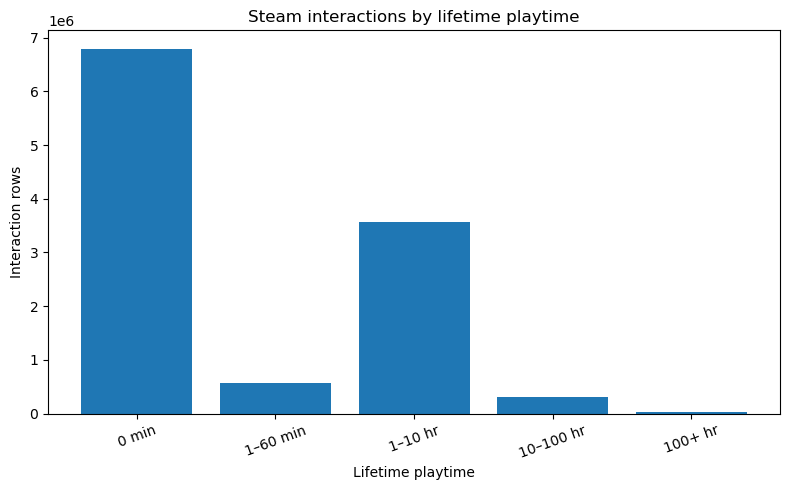

In [10]:
playtime_buckets = con.execute("""
SELECT
    CASE
        WHEN playtime_forever = 0 THEN '0 min'
        WHEN playtime_forever <= 60 THEN '1–60 min'
        WHEN playtime_forever <= 600 THEN '1–10 hr'
        WHEN playtime_forever <= 6000 THEN '10–100 hr'
        ELSE '100+ hr'
    END AS playtime_bucket,
    COUNT(*) AS interactions
FROM user_games
WHERE playtime_forever IS NOT NULL
GROUP BY 1
ORDER BY
    CASE playtime_bucket
        WHEN '0 min' THEN 1
        WHEN '1–60 min' THEN 2
        WHEN '1–10 hr' THEN 3
        WHEN '10–100 hr' THEN 4
        ELSE 5
    END
""").df()

display(playtime_buckets)

plt.figure(figsize=(8, 5))
plt.bar(playtime_buckets["playtime_bucket"], playtime_buckets["interactions"])
plt.title("Steam interactions by lifetime playtime")
plt.xlabel("Lifetime playtime")
plt.ylabel("Interaction rows")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. User activity distribution

,games_owned,total_playtime_minutes,games_played
count,786.000000,7.860000e+02,786.000000
mean,14357.875318,3.556237e+06,5710.003817
std,4603.727582,1.068639e+07,3535.226225
min,4455.000000,1.229100e+04,88.000000
25%,11361.000000,1.279047e+06,3223.000000
50%,12674.000000,1.978518e+06,6132.000000
75%,15660.750000,2.799377e+06,7377.750000
90%,20683.500000,4.701594e+06,8892.000000
95%,23254.750000,8.479808e+06,10641.500000
99%,33033.800000,4.049564e+07,16346.550000


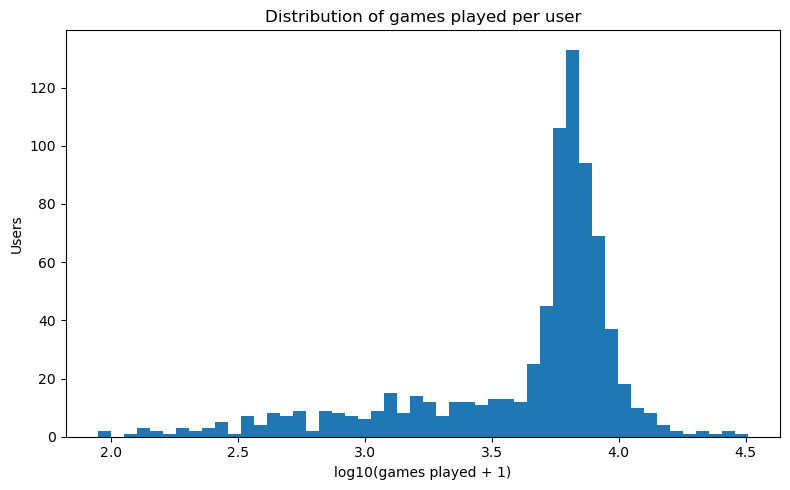

In [11]:
user_activity = con.execute("""
SELECT
    steamid,
    COUNT(*) AS games_owned,
    SUM(COALESCE(playtime_forever, 0)) AS total_playtime_minutes,
    SUM(CASE WHEN playtime_forever > 0 THEN 1 ELSE 0 END) AS games_played
FROM user_games
GROUP BY steamid
""").df()

display(user_activity.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 5))
plt.hist(np.log10(user_activity["games_played"] + 1), bins=50)
plt.title("Distribution of games played per user")
plt.xlabel("log10(games played + 1)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

Users with very few played games are difficult to model because the recommender has little behavioral history. This is a likely low-history/cold-start failure.

## 11. Game popularity distribution

,appid,game_name,user_interactions,users_with_playtime,total_playtime_minutes
0,46510,Syberia 2,786,593.0,182457.0
1,400,Portal,785,479.0,271559.0
2,46500,Syberia,785,614.0,130627.0
3,203160,Tomb Raider,785,694.0,2342440.0
4,235540,Warhammer: End Times - Vermintide,784,641.0,449245.0
5,329380,Stealth Inc 2,784,588.0,165136.0
6,504130,Manual Samuel - Last Tuesday Edition,784,585.0,165809.0
7,395170,DISTRAINT: Deluxe Edition,784,626.0,156357.0
8,3830,Psychonauts,784,681.0,248300.0
9,223470,POSTAL 2,784,653.0,396439.0


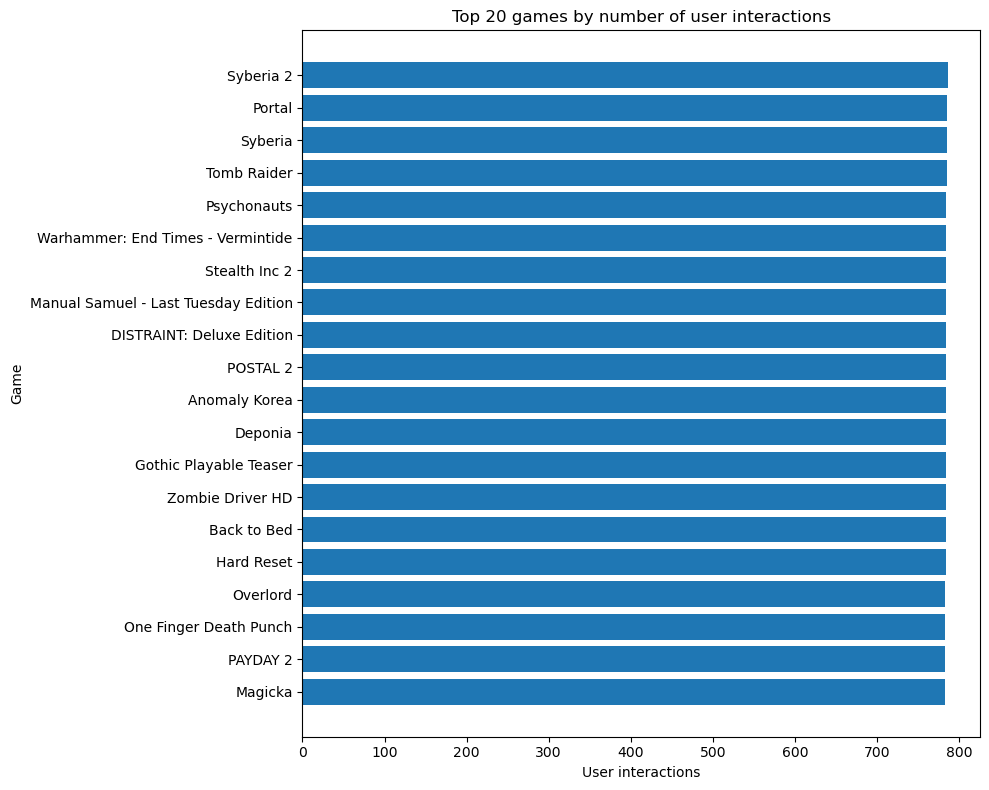

In [12]:
game_activity = con.execute("""
SELECT
    appid,
    ANY_VALUE(game_name) AS game_name,
    COUNT(*) AS user_interactions,
    SUM(CASE WHEN playtime_forever > 0 THEN 1 ELSE 0 END) AS users_with_playtime,
    SUM(COALESCE(playtime_forever, 0)) AS total_playtime_minutes
FROM user_games
GROUP BY appid
ORDER BY user_interactions DESC
""").df()

display(game_activity.head(20))
top_games = game_activity.head(20).sort_values("user_interactions")

#Config plt
plt.figure(figsize=(10, 8))
plt.barh(top_games["game_name"], top_games["user_interactions"])
plt.title("Top 20 games by number of user interactions")
plt.xlabel("User interactions")
plt.ylabel("Game")
plt.tight_layout()
plt.show()

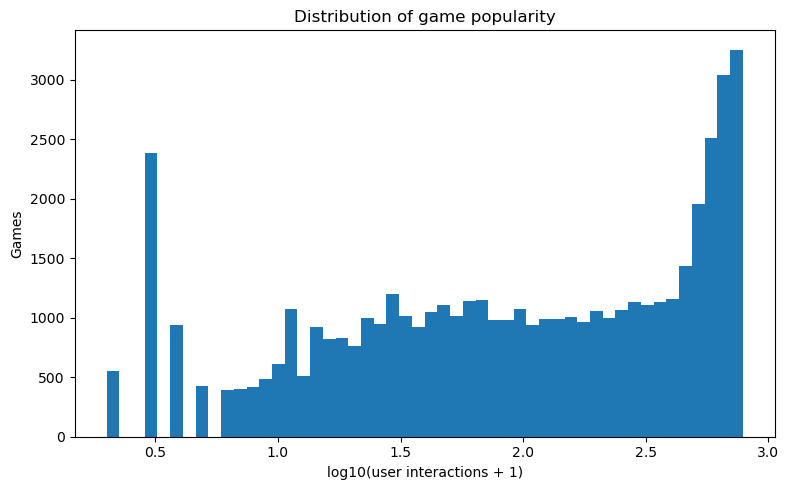

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(np.log10(game_activity["user_interactions"] + 1), bins=50)
plt.title("Distribution of game popularity")
plt.xlabel("log10(user interactions + 1)")
plt.ylabel("Games")
plt.tight_layout()
plt.show()

## 12. Popularity concentration / long tail

In [14]:
game_sorted = game_activity.sort_values("user_interactions", ascending=False).reset_index(drop=True)
game_sorted["cumulative_interactions"] = game_sorted["user_interactions"].cumsum()
total_game_interactions = game_sorted["user_interactions"].sum()
game_sorted["cumulative_share"] = (
    game_sorted["cumulative_interactions"] / total_game_interactions
)

for share in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, math.ceil(len(game_sorted) * share))
    interaction_share = (
        game_sorted.loc[:n-1, "user_interactions"].sum()
        / total_game_interactions
    )
    print(f"Top {share:.0%} of games account for {interaction_share:.2%} of interactions.")

Top 1% of games account for 3.43% of interactions.
Top 5% of games account for 16.52% of interactions.
Top 10% of games account for 31.64% of interactions.
Top 20% of games account for 57.49% of interactions.


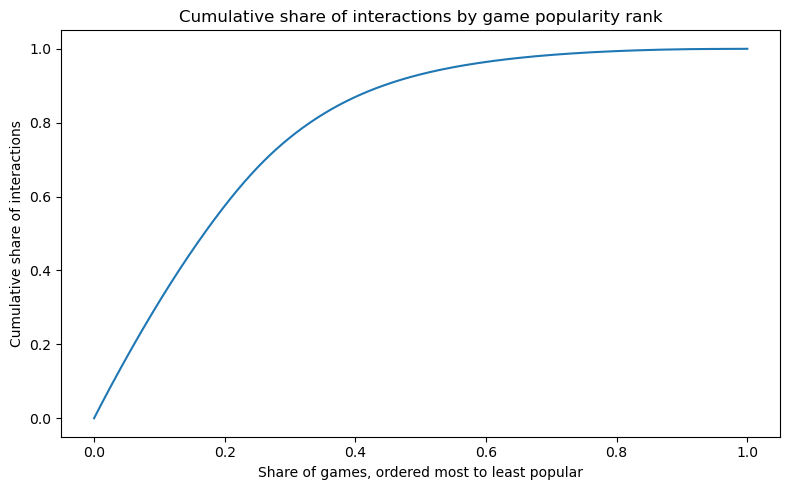

In [15]:
x = np.arange(1, len(game_sorted) + 1) / len(game_sorted)

plt.figure(figsize=(8, 5))
plt.plot(x, game_sorted["cumulative_share"])
plt.title("Cumulative share of interactions by game popularity rank")
plt.xlabel("Share of games, ordered most to least popular")
plt.ylabel("Cumulative share of interactions")
plt.tight_layout()
plt.show()

A concentrated interaction distribution creates **popularity bias**. A recommender can appear effective by repeatedly recommending blockbuster games, so later evaluation should also consider catalog coverage and performance on less-popular titles.

## 13. Metadata coverage

In [16]:
metadata_coverage = con.execute("""
WITH interaction_games AS (
    SELECT DISTINCT appid
    FROM user_games
)
SELECT
    COUNT(*) AS interaction_games,
    SUM(CASE WHEN g.appid IS NOT NULL THEN 1 ELSE 0 END) AS matched_to_metadata,
    SUM(CASE WHEN g.appid IS NULL THEN 1 ELSE 0 END) AS missing_metadata
FROM interaction_games i
LEFT JOIN games g USING (appid)
""").df()

metadata_coverage["coverage_pct"] = (
    metadata_coverage["matched_to_metadata"]
    / metadata_coverage["interaction_games"]
    * 100
)

metadata_coverage

,interaction_games,matched_to_metadata,missing_metadata,coverage_pct
0,49880,47729.0,2151.0,95.68765


## 14. Game metadata audit

In [ ]:
game_metadata_summary = con.execute("""
SELECT
    COUNT(*) AS games,
    SUM(CASE WHEN name IS NULL OR TRIM(name) = '' THEN 1 ELSE 0 END) AS missing_name,
    SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) AS missing_genres,
    SUM(CASE WHEN developers IS NULL THEN 1 ELSE 0 END) AS missing_developers,
    SUM(CASE WHEN publishers IS NULL THEN 1 ELSE 0 END) AS missing_publishers,
    SUM(CASE WHEN price_final IS NULL THEN 1 ELSE 0 END) AS missing_price,
    SUM(CASE WHEN release_date IS NULL THEN 1 ELSE 0 END) AS missing_release_date,
    SUM(CASE WHEN metacritic_score IS NULL THEN 1 ELSE 0 END) AS missing_metacritic
FROM games
""").df()

game_metadata_summary

DuckDB type for genres: VARCHAR[]


,genre,games
0,Indie,29421
1,Adventure,18780
2,Action,18327
3,Casual,16602
4,Simulation,10909
5,RPG,9887
6,Strategy,9608
7,Early Access,3615
8,Free To Play,2818
9,Sports,2154


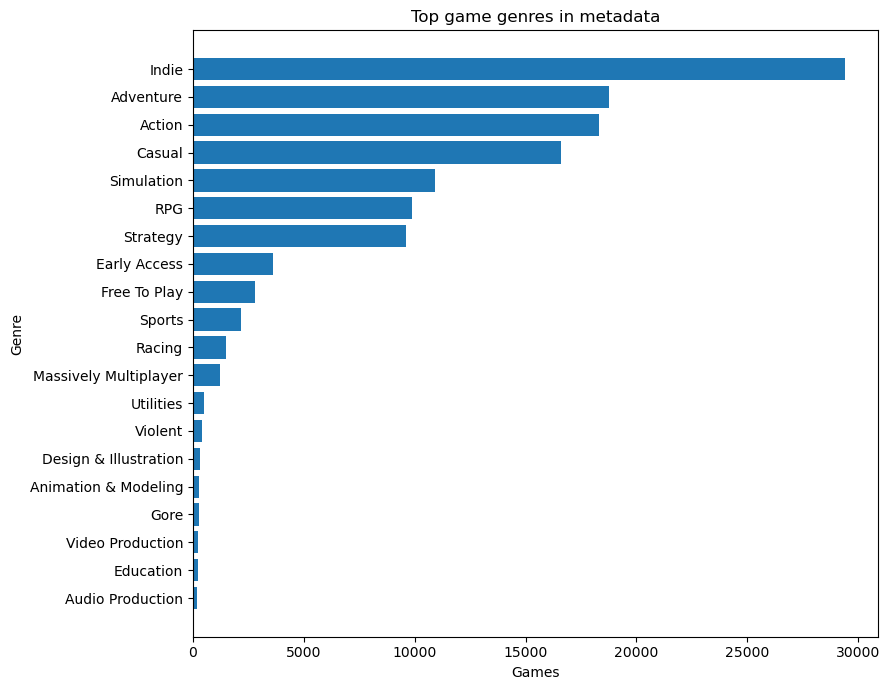

In [17]:
genre_type_row = con.execute("""
SELECT typeof(genres)
FROM games
WHERE genres IS NOT NULL
LIMIT 1
""").fetchone()

genre_dtype = genre_type_row[0] if genre_type_row else ""
print("DuckDB type for genres:", genre_dtype)

if "[]" in genre_dtype or "LIST" in genre_dtype.upper():
    genre_counts = con.execute("""
        SELECT genre, COUNT(*) AS games
        FROM games, UNNEST(genres) AS t(genre)
        WHERE genre IS NOT NULL
        GROUP BY genre
        ORDER BY games DESC
        LIMIT 20
    """).df()

    display(genre_counts)

    plot_genres = genre_counts.sort_values("games")
    plt.figure(figsize=(9, 7))
    plt.barh(plot_genres["genre"], plot_genres["games"])
    plt.title("Top game genres in metadata")
    plt.xlabel("Games")
    plt.ylabel("Genre")
    plt.tight_layout()
    plt.show()
else:
    print("Genres are not stored as a list type.")
    print("Inspect the sample values before deciding how to parse this field.")

## 15. Candidate positive-interaction thresholds

In [18]:
threshold_table = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN playtime_forever > 0 THEN 1 ELSE 0 END) AS played_gt_0,
    SUM(CASE WHEN playtime_forever >= 30 THEN 1 ELSE 0 END) AS played_ge_30_min,
    SUM(CASE WHEN playtime_forever >= 60 THEN 1 ELSE 0 END) AS played_ge_1_hr,
    SUM(CASE WHEN playtime_forever >= 120 THEN 1 ELSE 0 END) AS played_ge_2_hr
FROM user_games
""").df()

threshold_table

,total_rows,played_gt_0,played_ge_30_min,played_ge_1_hr,played_ge_2_hr
0,11285290,4488063.0,4131055.0,3920240.0,3301702.0


## 16. Evaluation plan

Because `user_games` does not include an interaction timestamp, the project cannot claim a chronological evaluation from this table alone.

The planned protocol is:

1. Filter to users with enough positive interactions for train/validation/test holdouts.
2. Define positive interactions using the playtime threshold justified above.
3. For each retained user, hold out at least one positive interaction for validation and one for test.
4. Keep the remaining positives in training.
5. Treat unobserved user–game pairs as candidate negatives rather than assuming every unobserved pair is truly disliked.
6. Use a fixed random seed so the split is reproducible.

### Primary metrics

- **Recall@10**
- **NDCG@10**
- **Hit Rate@10**
- **Catalog coverage**

### Check-in 2 comparison

1. Popularity recommender
2. Matrix-factorization / collaborative-filtering baseline
3. Neural Collaborative Filtering (NCF)

The NCF model will learn user and game embeddings and use an MLP to learn nonlinear user–game interactions.

## 17. Build Table for Check In 1

In [20]:
print("CHECK-IN 1")
print("=" * 50)
print(f"Interactions: {interactions:,}")
print(f"Users:        {n_users:,}")
print(f"Games:        {n_games:,}")
print(f"Sparsity:     {sparsity:.8%}")
print()
print("The analysis above covers:")
print("- representative samples and schema")
print("- missing values and duplicates")
print("- playtime distribution")
print("- user activity")
print("- game popularity and long-tail concentration")
print("- metadata coverage")
print("- biases and likely failure modes")
print("- evaluation protocol")

CHECK-IN 1
Interactions: 11,285,290
Users:        786
Games:        49,830
Sparsity:     71.18628273%

The analysis above covers:
- representative samples and schema
- missing values and duplicates
- playtime distribution
- user activity
- game popularity and long-tail concentration
- metadata coverage
- biases and likely failure modes
- evaluation protocol
